# Sekantmetoden

Me skal studera funksjonen
$f(x) = 3x^3 + 10x^2 - 50x - 3$, eller

In [1]:
def f(x): return 3*x**3 + 10*x**2 - 50*x - 3

Me lastar biblioteka med ein gong.

In [2]:
from matplotlib import pyplot as plt
%matplotlib inline

In [3]:
def fixaxes():
    ax = plt.gca()
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.spines['bottom'].set_position(('data',0))
    ax.spines['right'].set_color('none')
    ax.yaxis.set_ticks_position('left')

## Sekanten

Lat oss seia at me hev funksjonen $f$ og to punkt $x_0$ og $x_1$. Me skal sjå på sekanten som skjer kurva åt $f$ for $x=x_0$ og $x=x_1$.  Kam me illustrera det?

Lat oss freista med eit konkret døme.

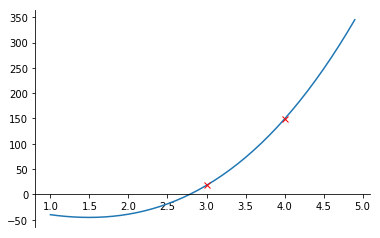

In [37]:
x1 = 4
x2 = 3
x = [ i/10 for i in range(10,50) ]
y = [ f(i) for i in x ]
plt.plot(x,y)
plt.plot( [x1,x2], [f(x1),f(x2)], "rx")
fixaxes()

Sekanten har stigningstalet
$$ a = \frac{f(x_2)-f(x_1)}{x_2-x_1}$$
og likninga
$$ y = \frac{f(x_2)-f(x_1)}{x_2-x_1}(x-x_1) + f(x_1)$$
Me kan laga ein `python`-funksjon som reknar ut punkta på sekanten:


In [11]:
def secant(f,x1,x2,x):
    f1 = f(x1)
    f2 = f(x2)
    a = (f2-f1)/(x2-x1)
    y = a*(x-x1)+ f1
    return y
y1 = [ secant(f,x1,x2,i) for i in x]

No kan me plotta funksjonen og sekanten saman.

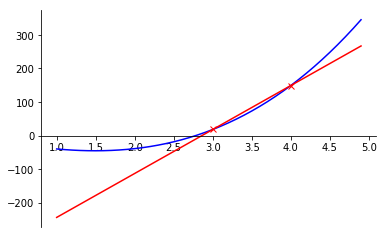

In [12]:
plt.plot(x,y,"b",x,y1,"r")
plt.plot( [x1,x2], [f(x1),f(x2)], "rx")
fixaxes()

Me kan pakka alt dette saman i ein funksjon som me kan bruka fleire gongar.


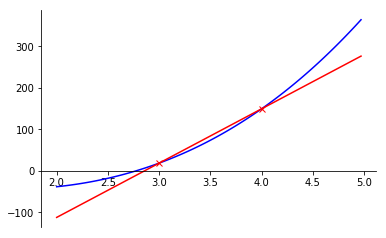

In [13]:
def plotsecant(f,x1,x2):
    xmin = 2*x1 - x2
    xmax = 2*x2 - x1
    x = [ xmin + i*(xmax-xmin)/100 for i in range(100)]
    y = [ f(i) for i in x ]
    y1 = [ secant(f,x1,x2,i) for i in x ]
    plt.plot(x,y,"b",x,y1,"r")
    plt.plot( [x1,x2], [f(x1),f(x2)], "rx")
    fixaxes()
plotsecant(f,3,4)

## Tabell som ekstrakontroll

Det er lett å gå i surr med kva dei ulike variablane tyder.
Der er mange måtar å inspisera på, og visualisera mellomstega.
I plottinga bruker me dei to listen `x` og `y`.
Det går an å visualisera dei som tabell.  Slik:

In [40]:
print( "x\ty")
for i in range(len(x)):
  print( x[i], "\t", y[i])

x	y
1.0 	 -40.0
1.1 	 -41.907000000000004
1.2 	 -43.416000000000004
1.3 	 -44.509
1.4 	 -45.168000000000006
1.5 	 -45.375
1.6 	 -45.111999999999995
1.7 	 -44.361000000000004
1.8 	 -43.10399999999999
1.9 	 -41.323
2.0 	 -39.0
2.1 	 -36.11699999999999
2.2 	 -32.65599999999999
2.3 	 -28.599000000000004
2.4 	 -23.92800000000001
2.5 	 -18.625
2.6 	 -12.671999999999997
2.7 	 -6.050999999999988
2.8 	 1.2559999999999718
2.9 	 9.266999999999996
3.0 	 18.0
3.1 	 27.473000000000013
3.2 	 37.704000000000065
3.3 	 48.710999999999984
3.4 	 60.51199999999997
3.5 	 73.125
3.6 	 86.56800000000004
3.7 	 100.85900000000004
3.8 	 116.01599999999996
3.9 	 132.05700000000002
4.0 	 149.0
4.1 	 166.86299999999997
4.2 	 185.664
4.3 	 205.42099999999994
4.4 	 226.15200000000007
4.5 	 247.875
4.6 	 270.60799999999995
4.7 	 294.36900000000014
4.8 	 319.17599999999993
4.9 	 345.04700000000014


## Eit steg i sekantmetoden

Sekantmetoden startar alltid med to estimat. Kvar runde byter ut eitt av estimata med skjæringspunktet mellom $x$-aksen og sekanten.  Dette punktet reknar me ut ved å løysa likninga
$$ 0 = \frac{f(x_1)-f(x0)}{x_1-x_0}(x-x_0) + f(x_0)$$
Dvs.
$$ x = x_0 - \frac{x_1-x_0}{f(x_1)-f(x0)}f(x_0)$$
Lat oss berre laga ein funksjon for å rekna ut dette.

In [14]:
def secantstep(f,x1,x2):
    return x1 - f(x1)*(x2-x1)/(f(x2)-f(x1))
x3 = secantstep(f,3,4)
print(x3)

2.8625954198473282


No kan me byta ut $x_3$ med $x_2=4$.  Me held på $x_1=3$ som ligg nærare $x_3$.

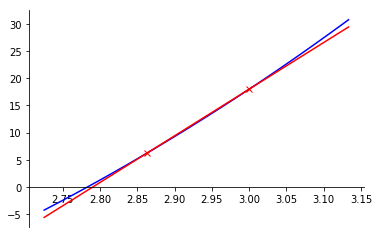

In [16]:
plotsecant(f,x3,x2)


## Åtvaring

Merk at sekantmetoden føreset relativt jamn krumming på kurva.
Det er relativt enkelt å konstruera døme der sekantmetoden divergerer.
So lenge ein er merksam på det, og vel ein annan metode om ein ikkje får det til, so er dette ikkje noko problem.  Ein kan alltid sjekka ved rekning, om løysinga er akseptabel.

## Oppgåve

Lag ein funksjon som gjentek sekantmetoden vha. ei løkke, og kjem fram til ei tilfredsstillande tilnærming til nullpunktet.

### Oppgåve 2

Når me evaluerer numeriske algoritmar, er det nyttig å sjå på korleis løysingsestimatet utviklar seg steg for steg. Lag ein funksjon som lagrar alle estimata undervegs i ei liste, og plottar estimatet som ein funksjon av stegnummeret. 